ahhh


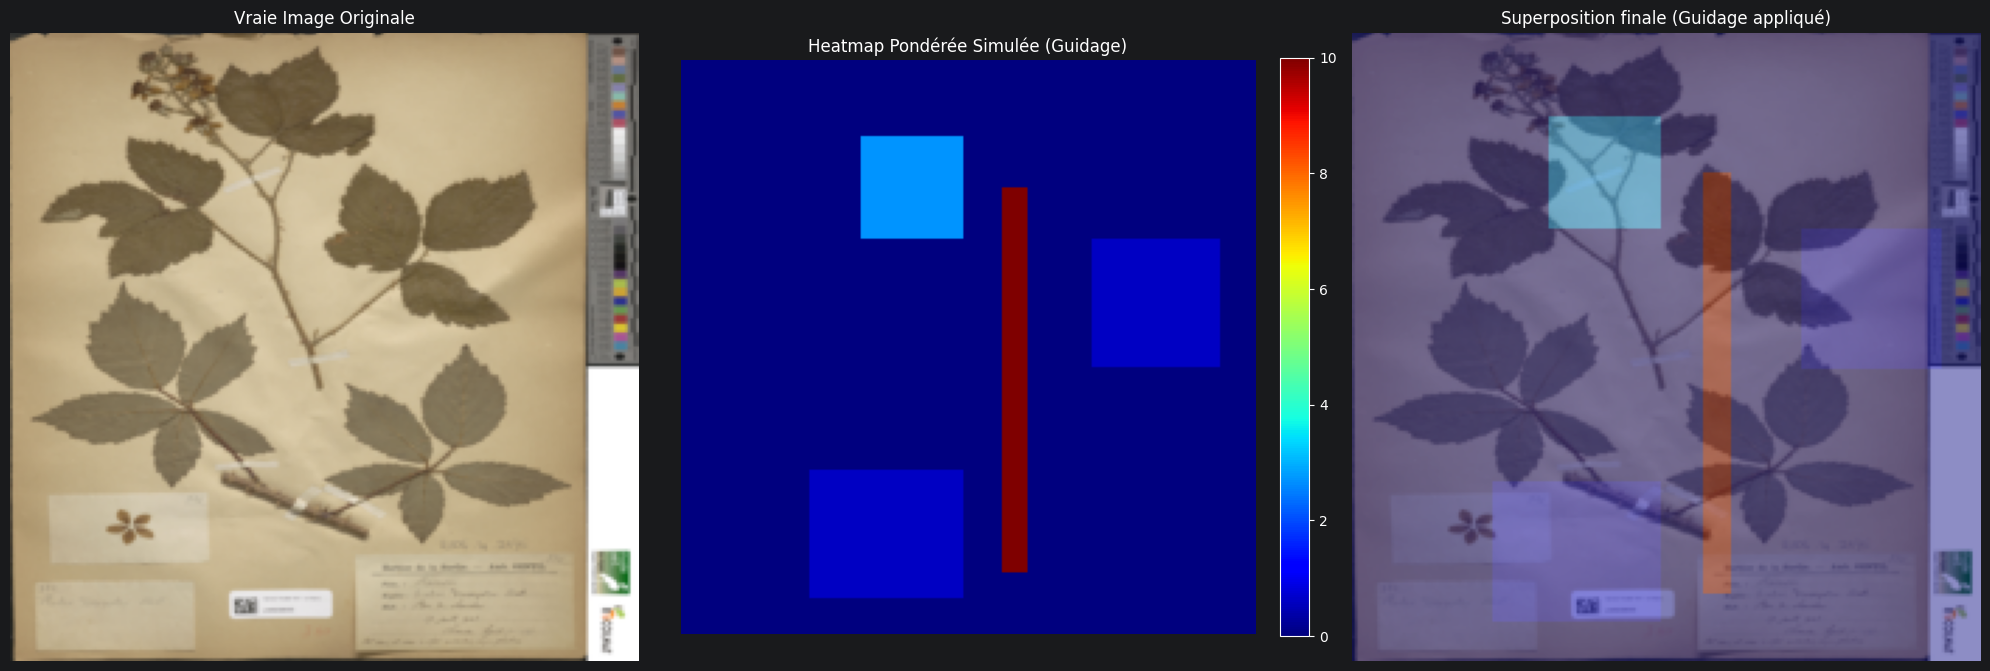

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# --- CONFIGURATION (Identique à ton script principal) ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BRANCHES_IMG_SIZE = (224, 224)
# Tes 7 Alphas : [épines, tige, feuille, etc...]
STRATEGIE_ALPHAS = torch.tensor([3.0, 1.0, 10.0, 1.0, 1.0, 1.0, 0.1]).to(DEVICE)


def preparer_image(image_path, size):
    """Charge une vraie image et la met au format tenseur [3, 224, 224]"""
    img = Image.open(image_path).convert("RGB")
    transform = T.Compose(
        [
            T.Resize(size),
            T.ToTensor(),  # Met en [0, 1] et C, H, W
        ]
    )
    return transform(img).to(DEVICE)


def simuler_poids_yolo_pour_image(image_tensor):
    """
    Simule des détections sur les vrais éléments de ta plante :
    - Tige centrale (Alpha 10.0)
    - Grappe de fleurs/fruits en haut (Alpha 3.0)
    - Quelques feuilles (Alpha 1.0)
    """
    _, H, W = image_tensor.shape
    weights_yolo = torch.zeros((7, H, W)).to(DEVICE)

    # 1. TIGE CENTRALE (Index 2, Alpha 10.0 -> Rouge vif)
    # Une ligne verticale qui suit la tige principale au milieu
    weights_yolo[2, 50:200, 125:135] = 1.0

    # 2. FLEURS / FRUITS EN HAUT (Index 0, Alpha 3.0 -> Orange/Jaune)
    # La zone sombre tout en haut à gauche de la tige
    weights_yolo[0, 30:70, 70:110] = 0.9

    # 3. FEUILLES DE DROITE (Index 1, Alpha 1.0 -> Bleu/Cyan)
    # La grande feuille à mi-hauteur sur la droite
    weights_yolo[1, 70:120, 160:210] = 0.6

    # 4. FEUILLE BAS GAUCHE (Index 1, Alpha 1.0 -> Bleu/Cyan)
    weights_yolo[1, 160:210, 50:110] = 0.6

    return weights_yolo


def generer_heatmap_entree_vraie_image(image_path):
    """
    Charge l'image, simule les poids, applique les Alphas et affiche.
    """
    # 1. Charger et préparer l'image
    try:
        img_tensor = preparer_image(image_path, BRANCHES_IMG_SIZE)
    except FileNotFoundError:
        print(f"Erreur : Image non trouvée au chemin '{image_path}'")
        return

    # 2. Simuler les Poids YOLO (Canaux=7)
    weights_yolo = simuler_poids_yolo_pour_image(img_tensor)

    # 3. Appliquer STRATEGIE_ALPHAS
    # Multiplication canal par canal et somme pour fusionner en 1 seule map [H, W]
    # On aligne Alphas [7] -> [7, 1, 1] pour la multiplication matricielle
    alphas_view = STRATEGIE_ALPHAS.view(-1, 1, 1)
    heatmap_combinee = (weights_yolo * alphas_view).sum(dim=0)

    # 4. Normalisation de la Heatmap finale pour l'affichage (0-1)
    heatmap_np = heatmap_combinee.cpu().numpy()
    heatmap_norm = (heatmap_np - heatmap_np.min()) / (heatmap_np.max() - heatmap_np.min() + 1e-8)

    # 5. Préparation de l'image pour affichage Matplotlib (H, W, C)
    img_np = img_tensor.cpu().permute(1, 2, 0).numpy()

    # 6. AFFICHAGE (Comparaison Original vs Guidage)
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # Vue 1 : L'image brute
    axes[0].imshow(img_np)
    axes[0].set_title("Vraie Image Originale")
    axes[0].axis("off")

    # Vue 2 : La Heatmap Combinaison des détections simulées
    axes[1].imshow(heatmap_norm, cmap="jet")
    axes[1].set_title("Heatmap Pondérée Simulée (Guidage)")
    # Barre d'échelle
    sm = plt.cm.ScalarMappable(
        cmap="jet", norm=plt.Normalize(vmin=heatmap_np.min(), vmax=heatmap_np.max())
    )
    sm._A = []
    fig.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04)
    axes[1].axis("off")

    # Vue 3 : Superposition (Ce que ton modèle reçoit pour se guider)
    axes[2].imshow(img_np)
    axes[2].imshow(heatmap_norm, cmap="jet", alpha=0.45)  # Alpha de transparence
    axes[2].set_title("Superposition finale (Guidage appliqué)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


# --- EXÉCUTION DANS LE NOTEBOOK ---
# REMPLACE PAR LE CHEMIN D'UNE VRAIE IMAGE SUR TON DISQUE
print("ahhh")
CHEMIN_DE_TON_IMAGE = "/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/epines/LMS09635.jpg"

generer_heatmap_entree_vraie_image(CHEMIN_DE_TON_IMAGE)

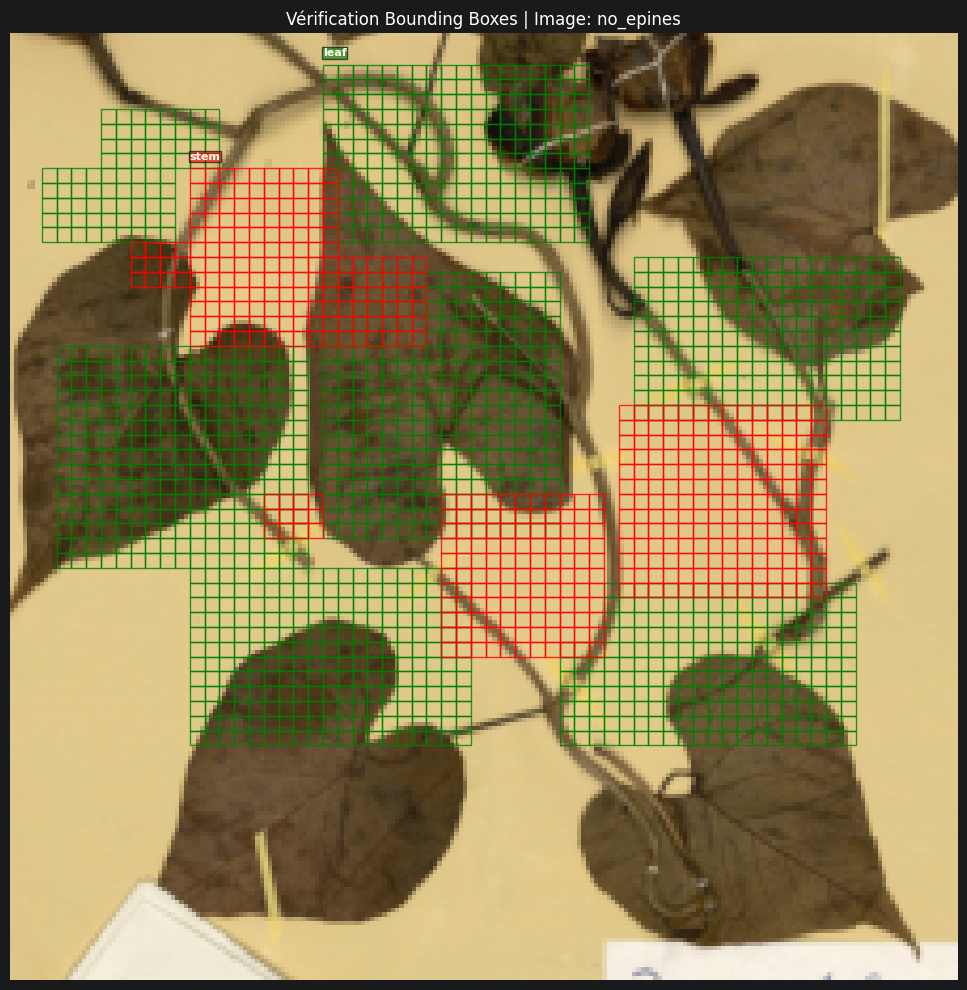

In [ ]:
import sys
import torch
import matplotlib.patches as patches
from pathlib import Path

# --- CONFIGURATION ---
src_path = str(Path.cwd() / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

from src.scripts.dataset_vic import DualInputDataset

DATA_PATH = Path("/mnt/2210B8B210B88E73/Documents/Ing 3/PFE/data/created_data")
CLASSES = ("no_epines", "epines")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

# Mapping de tes classes YOLO (0:leaf, 1:root, 2:stem, 3:flower, 4:fruit, 5:seed, 6:fond)
YOLO_NAMES = ["leaf", "root", "stem", "flower", "fruit", "seed", "background"]
COLORS = ["green", "brown", "red", "purple", "orange", "yellow", "gray"]


def test_dataset_bboxes():
    # 1. Instanciation
    ds = DualInputDataset(
        data_dir=DATA_PATH,
        is_train=False,
        image_size=(IMG_SIZE, IMG_SIZE),
        classes=CLASSES,
        paths=("original", "original"),
        use_yolo_weights=True,
        num_patches=8,
    )

    if len(ds) == 0:
        print("Dataset vide.")
        return

    # 2. Récupération d'un échantillon
    selected_patches, img_large, label, weights = ds[0]

    # 3. Préparation de l'image (Dénormalisation)
    img_np = img_large.permute(1, 2, 0).cpu().numpy()
    img_np = np.array([0.229, 0.224, 0.225]) * img_np + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    # 4. AFFICHAGE
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img_np)
    ax.set_title(f"Vérification Bounding Boxes | Image: {CLASSES[label]}")

    # 5. Extraction des BBoxes
    grid_h, grid_w = weights.shape[1], weights.shape[2]
    cell_size = IMG_SIZE / grid_h

    for cls_idx in range(len(YOLO_NAMES)):
        # On ne traite pas le fond (background) pour ne pas polluer l'image
        if YOLO_NAMES[cls_idx] == "background":
            continue

        mask = weights[cls_idx].cpu().numpy()
        y_coords, x_coords = np.where(mask > 0)

        for y, x in zip(y_coords, x_coords):
            # --- CORRECTION ICI ---
            # x_pixel (horizontal) = index colonne * taille cellule
            # y_pixel (vertical)   = index ligne * taille cellule
            rect_x = x * cell_size
            rect_y = y * cell_size

            rect = patches.Rectangle(
                (rect_x, rect_y),
                cell_size,
                cell_size,
                linewidth=1,
                edgecolor=COLORS[cls_idx],
                facecolor="none",
                alpha=0.8,
            )
            ax.add_patch(rect)

            # Label de classe (une seule fois par zone pour la clarté)
            if len(y_coords) > 0 and (y, x) == (y_coords[0], x_coords[0]):
                ax.text(
                    rect_x,
                    rect_y - 2,
                    YOLO_NAMES[cls_idx],
                    color="white",
                    weight="bold",
                    fontsize=8,
                    bbox=dict(facecolor=COLORS[cls_idx], alpha=0.6, pad=0.5),
                )

    ax.axis("off")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    test_dataset_bboxes()